# Extrapolation test

Forecast the next **300 days** of all seven series after the end of the observed dataset using a simple VAR(2) with Gaussian innovations.

The recipe:

1. Load and clean `spiff_data-2.csv` (replace the `1000` sentinels, restrict to the common gap-free window from day 1449).
2. Compute centered simple returns $r_t = P_t / P_{t-1} - 1 - \bar r$.
3. Fit a VAR(2): $r_t = \Phi_1 r_{t-1} + \Phi_2 r_{t-2} + \varepsilon_t$ by OLS, and estimate the residual covariance $\Sigma_\varepsilon$.
4. Seed with the last two observed return vectors and iterate forward for 300 steps using draws $\varepsilon_t \sim \mathcal N(0, \Sigma_\varepsilon)$ via a Cholesky factor.
5. Add the mean back and cumulate to get a price path starting from the last observed price.

This is a deliberately simple version of the DGP — no stochastic volatility, no $t$-copula. The cross-sectional correlation structure comes entirely from $\Sigma_\varepsilon$; the temporal dynamics come from $\Phi_1, \Phi_2$.


## 1. Setup and data loading

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

df_raw = pd.read_csv('../data/spiff_data-2.csv')
df_raw = df_raw.drop(columns=['Unnamed: 0']).set_index('day')

# Replace 1000-sentinels with NaN, restrict to the common gap-free window
df_prices = df_raw.replace(1000, np.nan).loc[1449:].dropna()
print(f"Clean price panel: {df_prices.shape}, days {int(df_prices.index[0])}..{int(df_prices.index[-1])}")
df_prices.tail()


Clean price panel: (3805, 7), days 1449..5256


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
5252,13.790362,8.236738,6.451460,6.706903,2.972465,8.751953,11.767324
5253,13.798624,8.134064,6.406032,6.677940,2.960002,8.730038,11.830896
5254,13.800276,8.191484,6.444321,6.655631,2.837448,8.748910,12.129688
5255,13.773631,8.123846,6.370987,6.593250,2.851988,8.742213,12.118563
5256,13.791949,8.084917,6.419011,6.512971,2.760591,8.738561,12.231405


## 2. Centered simple returns

We use simple (not log) returns centered at zero, matching the convention used in `500_sim_final.ipynb`. The mean is added back later before cumulating.


In [63]:
df_returns = df_prices.pct_change().dropna()
mean_return = df_returns.mean()
df_returns_centered = df_returns - mean_return
print("Per-series mean return:")
print(mean_return.round(6))
df_returns_centered.head()


Per-series mean return:
gurkor          0.000174
guitars         0.000164
slingshots      0.000361
stocks          0.000221
sugar           0.000130
water           0.000138
tranquillity    0.000172
dtype: float64


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
1450,0.005698,-0.032296,-0.041457,-0.015296,-0.000130,0.008441,-0.015129
1451,0.012296,-0.039841,-0.016218,0.003627,-0.021076,0.010140,-0.005233
1452,-0.005415,0.002681,0.029397,-0.014511,-0.049819,-0.002857,-0.000899
1453,-0.001227,0.028212,0.010114,0.002191,0.039812,-0.003920,-0.004899
1454,-0.001229,-0.007420,0.003095,0.004799,-0.000130,0.003569,0.003116


## 3. Fit VAR(2) by OLS

Stack the regressors $[r_{t-1}, r_{t-2}]$ and solve $r_t = [\Phi_1\;\Phi_2]\,[r_{t-1};\,r_{t-2}] + \varepsilon_t$ jointly via least squares. The residual sample covariance gives $\hat\Sigma_\varepsilon$; its Cholesky factor is the noise driver for the simulation.


In [64]:
Y = df_returns_centered.values                # (T, 7)
T, k = Y.shape

# Build lagged regressors
X = np.column_stack([Y[1:-1], Y[:-2]])        # (T-2, 14): [r_{t-1}, r_{t-2}]
Y_t = Y[2:]                                   # (T-2, 7)

# OLS: B has shape (14, 7); rows 0..6 -> Phi1^T, rows 7..13 -> Phi2^T
B, *_ = np.linalg.lstsq(X, Y_t, rcond=None)
Phi1 = B[:k].T
Phi2 = B[k:].T

# Residual covariance
resid = Y_t - X @ B
Sigma_eps = np.cov(resid, rowvar=False)
L_eps = np.linalg.cholesky(Sigma_eps + 1e-12 * np.eye(k))

print("Phi1 diagonal:", np.round(np.diag(Phi1), 3))
print("Phi2 diagonal:", np.round(np.diag(Phi2), 3))
print(f"Residual std (per series): {np.round(np.sqrt(np.diag(Sigma_eps)), 5)}")


Phi1 diagonal: [-0.029 -0.139 -0.107 -0.015 -0.185 -0.129 -0.055]
Phi2 diagonal: [-0.079 -0.055  0.014 -0.023 -0.077 -0.013  0.003]
Residual std (per series): [0.00406 0.01566 0.01623 0.01484 0.01362 0.00347 0.01323]


### Stability check

For a VAR(2) the companion matrix $\begin{bmatrix}\Phi_1 & \Phi_2\\ I & 0\end{bmatrix}$ must have all eigenvalues inside the unit circle. Otherwise the forecast will blow up.


In [65]:
companion = np.block([[Phi1, Phi2], [np.eye(k), np.zeros((k, k))]])
eigs = np.linalg.eigvals(companion)
print(f"Max |eigenvalue| of companion: {np.max(np.abs(eigs)):.4f}")
assert np.max(np.abs(eigs)) < 1, "VAR(2) is non-stationary"


Max |eigenvalue| of companion: 0.2947


## 4. Extrapolate 300 days

Seed with the last two observed return vectors $r_{T-1}, r_T$ and roll the VAR forward, drawing $\varepsilon_t = L\,z_t$ with $z_t \sim \mathcal N(0, I)$ at each step.


In [66]:
np.random.seed(7)
H = 1000

last_price = df_prices.iloc[-1].values
last_day = int(df_prices.index[-1])

Y_extrap = np.zeros((H + 2, k))
Y_extrap[0] = Y[-2]
Y_extrap[1] = Y[-1]
for t in range(2, H + 2):
    eps =  L_eps @ np.random.randn(k)
    Y_extrap[t] = Phi1 @ Y_extrap[t - 1] + Phi2 @ Y_extrap[t - 2] + eps

# Add the mean back, cumulate from the last observed price
returns_extrap = Y_extrap[2:] + mean_return.values
prices_extrap = last_price * np.cumprod(1.0 + returns_extrap, axis=0)
future_days = np.arange(last_day + 1, last_day + 1 + H)
df_extrap = pd.DataFrame(prices_extrap, index=future_days, columns=var_names)
df_extrap.index.name = 'day'
df_extrap.head()


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
5257,13.891039,7.978651,6.338960,6.540072,2.737627,8.777492,12.187603
5258,13.790381,8.175645,6.507602,6.488554,2.737294,8.756625,12.228783
5259,13.775964,8.035534,6.475174,6.495087,2.778238,8.715780,12.487004
5260,13.790858,7.987004,6.613187,6.497722,2.709304,8.713692,12.112301
5261,13.847236,7.968795,6.478709,6.584555,2.664013,8.744725,11.789483


## 5. Plot observed tail + extrapolation

Blue is the last 500 days of observed prices, orange is the 300-day extrapolation. The dashed grey line marks the splice point.


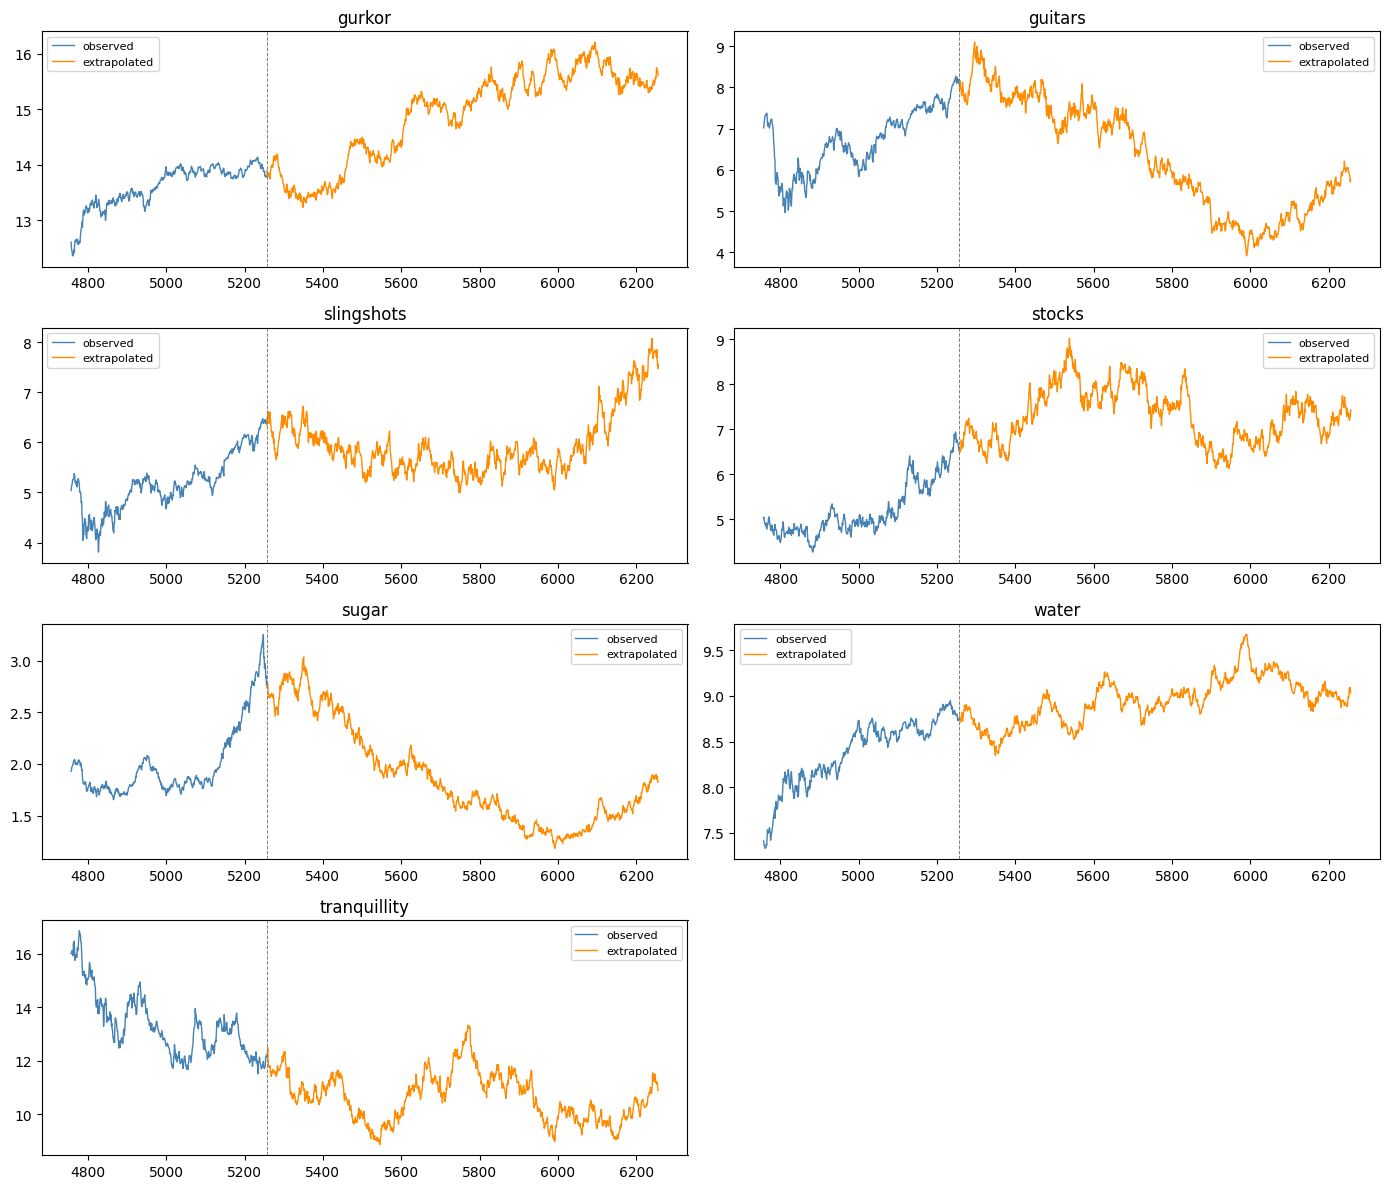

In [67]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
tail = 500
for ax, col in zip(axes.flat, var_names):
    ax.plot(df_prices.index[-tail:], df_prices[col].iloc[-tail:],
            color='steelblue', lw=1, label='observed')
    ax.plot(df_extrap.index, df_extrap[col],
            color='darkorange', lw=1, label='extrapolated')
    ax.axvline(last_day, color='grey', lw=0.7, ls='--')
    ax.set_title(col)
    ax.legend(loc='best', fontsize=8)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()


## 6. Sanity check: simulated vs. observed return moments

A quick comparison of per-series standard deviations and the cross-sectional correlation matrix. Because the innovations are Gaussian and homoskedastic, we don't expect the simulation to match the heavy tails or volatility clustering of the original — just the linear dependence and unconditional variance.


In [68]:
compare = pd.DataFrame({
    'obs_std':  df_returns_centered.std(),
    'sim_std':  pd.Series(Y_extrap[2:].std(axis=0), index=var_names),
})
print(compare.round(5))

print("\nObserved correlation:")
obs_corr = df_returns_centered.corr()
print(obs_corr.round(2))

print("\nSimulated correlation (300 days — noisy):")
sim_corr = pd.DataFrame(Y_extrap[2:], columns=var_names).corr()
print(sim_corr.round(2))

# Calculate MAE for correlation matrices
mae_corr = np.abs(obs_corr - sim_corr).values.mean()
print(f"\nMAE (correlation matrices): {mae_corr:.5f}")

              obs_std  sim_std
gurkor        0.00408  0.00399
guitars       0.01604  0.01591
slingshots    0.01636  0.01662
stocks        0.01487  0.01456
sugar         0.01578  0.01536
water         0.00354  0.00345
tranquillity  0.01334  0.01329

Observed correlation:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00    -0.33       -0.29   -0.05  -0.08   0.62         -0.15
guitars        -0.33     1.00        0.55    0.03   0.22  -0.37          0.27
slingshots     -0.29     0.55        1.00    0.02   0.13  -0.26          0.21
stocks         -0.05     0.03        0.02    1.00  -0.02  -0.05          0.00
sugar          -0.08     0.22        0.13   -0.02   1.00  -0.09          0.14
water           0.62    -0.37       -0.26   -0.05  -0.09   1.00         -0.18
tranquillity   -0.15     0.27        0.21    0.00   0.14  -0.18          1.00

Simulated correlation (300 days — noisy):
              gurkor  guitars  slingshots  stocks  sugar  wate

## 7. Conditional variance (GARCH) correlation

Fit a GARCH(1,1) with zero mean to each series, both on the observed returns and on the 300-day extrapolation, then compare the cross-sectional correlation of the log conditional variances. This is the structure the full DGP in `500_sim_final.ipynb` works hard to recover via PCA on log-vol; here we expect the simple homoskedastic VAR to **miss it almost entirely** — conditional vol on the simulated path is driven only by the rolling sample variance of the VAR residuals, which is i.i.d. by construction. The interesting question is *how much* signal survives anyway.


Off-diagonal MAE on log-vol correlations: 0.459


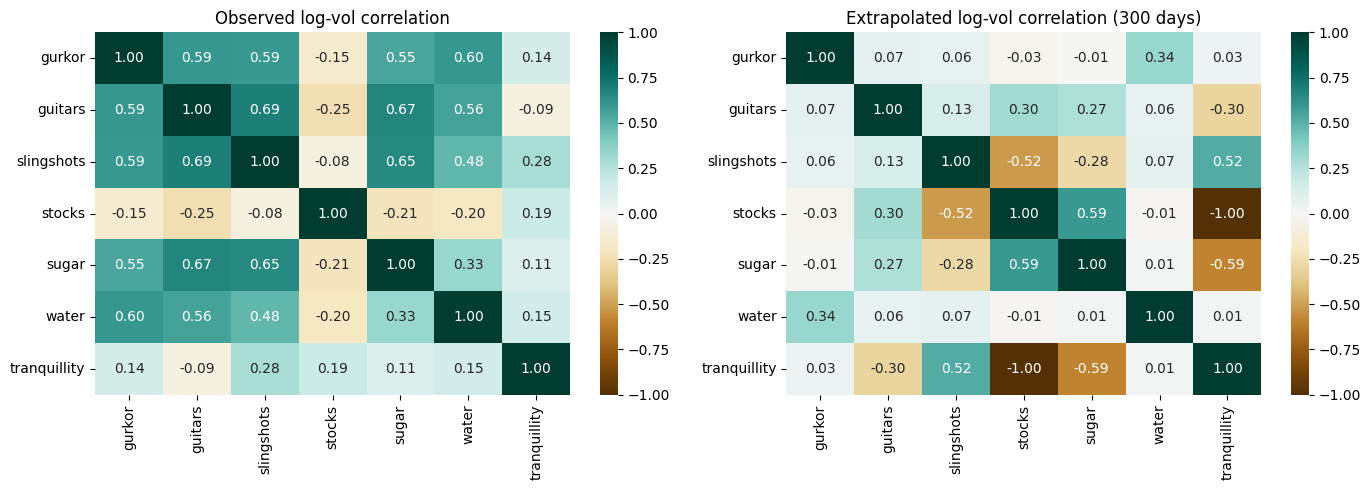

In [69]:
from arch import arch_model

def fit_log_h(returns_df):
    out = pd.DataFrame(index=returns_df.index, columns=returns_df.columns, dtype=float)
    for col in returns_df.columns:
        # scale up to keep the optimizer happy (arch prefers ~1-sized series)
        res = arch_model(returns_df[col] * 1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
        out[col] = np.log(res.conditional_volatility ** 2)
    return out

# Observed: use the same centered returns we trained the VAR on
log_h_obs = fit_log_h(df_returns_centered)

# Simulated: rebuild centered returns from the extrapolation
df_sim_returns = pd.DataFrame(Y_extrap[2:], index=future_days, columns=var_names)
log_h_sim = fit_log_h(df_sim_returns)

corr_obs = log_h_obs.corr()
corr_sim = log_h_sim.corr()

mask = ~np.eye(k, dtype=bool)
mae_vol_corr = np.mean(np.abs(corr_obs.values[mask] - corr_sim.values[mask]))
print(f"Off-diagonal MAE on log-vol correlations: {mae_vol_corr:.3f}")

import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_obs, annot=True, fmt='.2f', cmap='BrBG', center=0,
            vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Observed log-vol correlation')
sns.heatmap(corr_sim, annot=True, fmt='.2f', cmap='BrBG', center=0,
            vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Extrapolated log-vol correlation (300 days)')
plt.tight_layout()
plt.show()


### What this shows

The observed panel has strong shared volatility (gurkor / guitars / slingshots / sugar / water cluster tightly). The extrapolation can't reproduce it, because its innovations are i.i.d. Gaussian — any apparent vol correlation on the simulated path is sampling noise from 300 observations, not structure. This is the headline limitation of the simple version and the reason `500_sim_final.ipynb` adds PCA-on-log-vol factors.

## Other tests worth running

If you want to push this further, the most informative additions would be:

- **Marginal tails / kurtosis.** Compare per-series excess kurtosis and run a Q–Q plot of simulated vs. observed standardized returns. The Gaussian VAR will visibly under-produce tails.
- **ARCH-LM test** (`statsmodels.stats.diagnostic.het_arch`) on returns and on the VAR(2) residuals — quantifies the volatility clustering the simulation is missing.
- **Squared-return ACF.** Plot $\mathrm{ACF}(r_t^2)$ for observed vs. simulated; observed will show slow decay (long memory in vol), simulated will be flat — a clean visual of the same gap.
- **Ljung–Box on residuals.** Confirms the VAR(2) has soaked up the linear autocorrelation (no remaining mean structure). If it hasn't, raise the order.
- **Forecast-fan check.** Run the extrapolation 200–1000 times with different seeds and overlay the price paths to show the simulated uncertainty cone; compare its width at $H=300$ to a bootstrap of 300-day windows from the observed data.
- **Impulse response stability.** Plot the IRF of each series to a unit shock in each other series — sanity-check that the fitted $\Phi_1, \Phi_2$ match the hardcoded ones in `500_sim_final.ipynb`.
- **In-sample backtest.** Hold out the last 300 observed days, refit on the rest, extrapolate, and compare to truth (RMSE on prices, calibration of forecast intervals from a Monte Carlo).

The backtest and the squared-return ACF would probably give you the most insight per minute of work.


## 8. Multivariate-t innovations

Replace the Gaussian draws with a Gaussian scale mixture:

$$ \varepsilon_t = \sqrt{\nu / G_t}\; L_\varepsilon\, z_t,\quad z_t \sim \mathcal N(0, I),\quad G_t \sim \chi^2_\nu $$

This is exactly the multivariate-$t$ with shape $\Sigma_\varepsilon$. A *single* scale $G_t$ is shared across all seven series, so heavy-tail days inflate every series simultaneously — that's the contemporaneous vol-correlation we were missing.

Estimate $\nu$ from the residuals via the Mahalanobis-distance moment estimator: under MV-$t$, $\mathbb E[d^2] = k\nu/(\nu-2)$, so $\hat\nu = 2\bar d^2 / (\bar d^2 - k)$. Rescale the Cholesky factor by $\sqrt{(\nu-2)/\nu}$ so the simulated innovations keep the same covariance $\Sigma_\varepsilon$.


In [ ]:
from scipy.stats import chi2

# Estimate nu from Mahalanobis distances of the observed VAR residuals
Sigma_inv = np.linalg.inv(Sigma_eps)
d2 = np.einsum('ti,ij,tj->t', resid, Sigma_inv, resid)
mean_d2 = d2.mean()
nu_hat = 2 * mean_d2 / (mean_d2 - k)
nu_hat = max(nu_hat, 4.5)  # guard against absurd values (need nu>4 for finite kurt)
print(f"Estimated nu: {nu_hat:.2f}  (mean Mahalanobis d^2 = {mean_d2:.2f}, k = {k})")

# Rescale L so MV-t has covariance = Sigma_eps (since Cov(MV-t) = nu/(nu-2) * shape)
L_mvt = L_eps * np.sqrt((nu_hat - 2) / nu_hat)

np.random.seed(7)
Y_extrap_t = np.zeros((H + 2, k))
Y_extrap_t[0] = Y[-2]
Y_extrap_t[1] = Y[-1]
for t in range(2, H + 2):
    g = chi2.rvs(nu_hat)
    eps = np.sqrt(nu_hat / g) * (L_mvt @ np.random.randn(k))
    Y_extrap_t[t] = Phi1 @ Y_extrap_t[t - 1] + Phi2 @ Y_extrap_t[t - 2] + eps

returns_extrap_t = Y_extrap_t[2:] + mean_return.values
prices_extrap_t = last_price * np.cumprod(1.0 + returns_extrap_t, axis=0)
df_extrap_t = pd.DataFrame(prices_extrap_t, index=future_days, columns=var_names)
df_extrap_t.index.name = 'day'


Estimated nu: 4.50  (mean Mahalanobis d^2 = 7.00, k = 7)


### Compare: kurtosis and vol correlation, Gaussian vs MV-t

Excess kurtosis:
                obs  sim_gauss  sim_mvt
gurkor         3.59       0.10     5.57
guitars        5.72       0.11    10.65
slingshots     4.68       0.05    15.67
stocks         0.05      -0.07     5.11
sugar         13.46      -0.21     4.16
water          1.64      -0.20    11.74
tranquillity   2.58      -0.09     2.47

Log-vol correlation MAE — Gaussian: 0.459   MV-t: 0.553


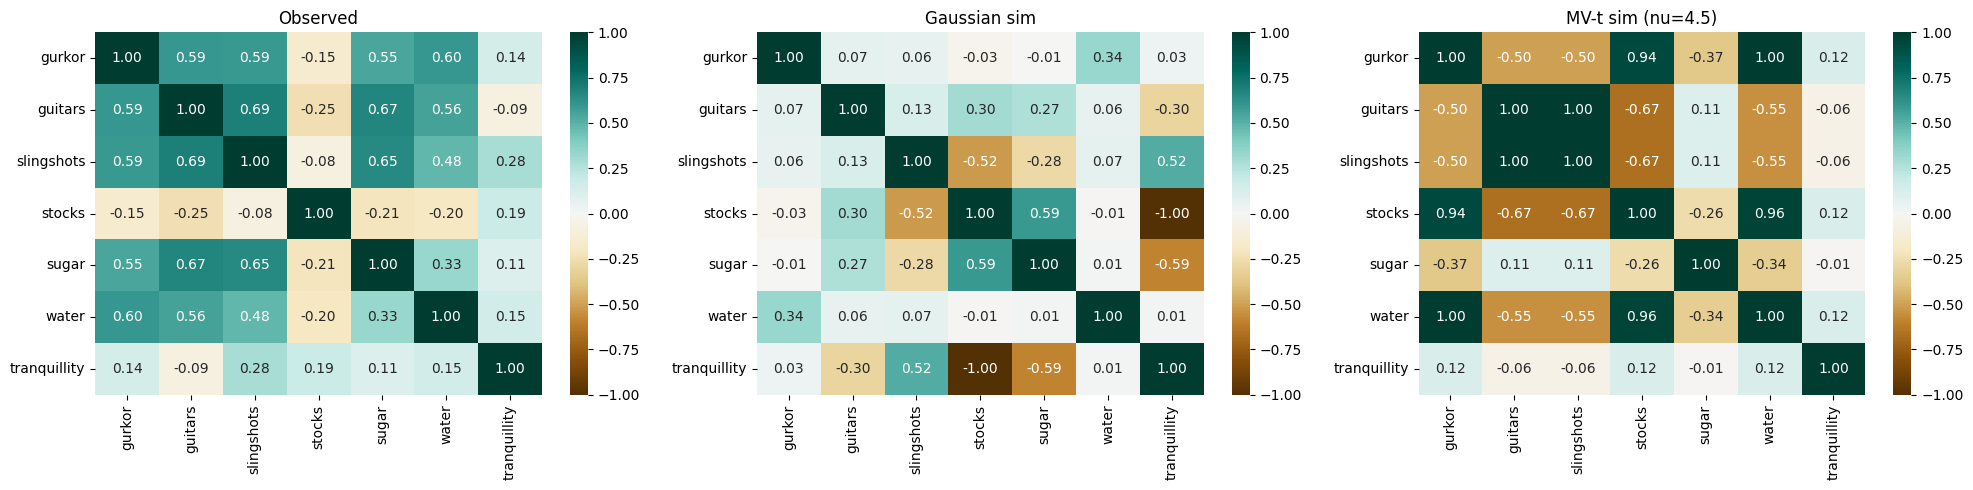

In [75]:
# Marginal kurtosis comparison
kurt = pd.DataFrame({
    'obs':       df_returns_centered.kurt(),
    'sim_gauss': pd.DataFrame(Y_extrap[2:],   columns=var_names).kurt(),
    'sim_mvt':   pd.DataFrame(Y_extrap_t[2:], columns=var_names).kurt(),
})
print("Excess kurtosis:")
print(kurt.round(2))

# Refit GARCH on MV-t simulation, compare log-vol correlation
df_sim_returns_t = pd.DataFrame(Y_extrap_t[2:], index=future_days, columns=var_names)
log_h_sim_t = fit_log_h(df_sim_returns_t)
corr_sim_t = log_h_sim_t.corr()

mae_gauss = np.mean(np.abs(corr_obs.values[mask] - corr_sim.values[mask]))
mae_mvt   = np.mean(np.abs(corr_obs.values[mask] - corr_sim_t.values[mask]))
print(f"\nLog-vol correlation MAE — Gaussian: {mae_gauss:.3f}   MV-t: {mae_mvt:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.heatmap(corr_obs,   annot=True, fmt='.2f', cmap='BrBG', center=0,
            vmin=-1, vmax=1, ax=axes[0]); axes[0].set_title('Observed')
sns.heatmap(corr_sim,   annot=True, fmt='.2f', cmap='BrBG', center=0,
            vmin=-1, vmax=1, ax=axes[1]); axes[1].set_title('Gaussian sim')
sns.heatmap(corr_sim_t, annot=True, fmt='.2f', cmap='BrBG', center=0,
            vmin=-1, vmax=1, ax=axes[2]); axes[2].set_title(f'MV-t sim (nu={nu_hat:.1f})')
plt.tight_layout()
plt.show()
